# DeepExtractor — Training Tutorial (Google Colab)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tomdooney95/deepextractor/blob/main/notebooks/training_tutorial_colab.ipynb)

This notebook trains a fresh DeepExtractor model from scratch on synthetic (`numpy`) noise, plots the training losses, and tests the model on sine-Gaussian injections. It is designed to run on Google Colab with a free T4 GPU.

> **Tip:** Go to Runtime → Change runtime type → GPU before running.

In [ ]:
!pip install deepextractor

In [7]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

from deepextractor.models.architectures import UNET2D
from deepextractor.generation.generate_timeseries import (
    generate_gaussian_noise, generate_synthetic_data, LENGTH, SAMPLE_RATE, T
)
from deepextractor.generation.glitch_functions import generate_sine_gaussian
from deepextractor.utils.signal import whitened_snr_scaling
from deepextractor.training.train_fn import train_fn
from deepextractor.utils.io import check_accuracy


## Configuration

In [8]:
# Device — uses MPS on Apple Silicon, CUDA on Linux/Windows GPU, otherwise CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

# Dataset size — keep small for a quick demo; increase for real training
N_TRAIN = 1000
N_VAL   = 200

# Training
BATCH_SIZE              = 32
EPOCHS                  = 50    # maximum epochs; early stopping may stop sooner however, this specific architecture will likely converge at a much higher epoch
LR                      = 1e-4
LR_PATIENCE             = 4     # epochs without improvement before LR is reduced
LR_FACTOR               = 0.1   # factor to reduce LR by
EARLY_STOPPING_PATIENCE = 9     # epochs without improvement before training stops

# STFT parameters
# Original DeepExtractor (arXiv:2501.18423): N_FFT=512, WIN_LENGTH=64, HOP_LENGTH=32
# → produces (257, 257) spectrograms, richer time-frequency representation
#   but significantly slower to train.
# Tutorial default: smaller spectrograms for faster training, but still gives decent performance (please see 129x129 model in the paper).
N_FFT      = 256
WIN_LENGTH = N_FFT // 2
HOP_LENGTH = WIN_LENGTH // 2


Using device: mps


## Step 1 — Generate synthetic time-domain data

Each training sample is a pair:
- **Input** `glitch`: background noise with 1–30 synthetic signal injections (chirps, sine-Gaussians, etc.)
- **Target** `background`: the same noise without any injections

The model learns to map glitchy strain → clean background.

In [9]:
mean, std_dev = 0, np.sqrt(SAMPLE_RATE / 2)  # PyCBC convention: variance = SAMPLE_RATE / 2

print("Generating training noise...")
train_noise = generate_gaussian_noise(mean, std_dev, N_TRAIN, (LENGTH,), bilby_noise=False)
print("Generating validation noise...")
val_noise   = generate_gaussian_noise(mean, std_dev, N_VAL,   (LENGTH,), bilby_noise=False)

print("Generating training pairs...")
glitch_train, bg_train = generate_synthetic_data(train_noise, bilby_noise=False, phase="train")
print("Generating validation pairs...")
glitch_val,   bg_val   = generate_synthetic_data(val_noise,   bilby_noise=False, phase="val")

print(f"\nTrain: {glitch_train.shape}  |  Val: {glitch_val.shape}")

Generating training noise...
Generating pycbc noise...
Generating validation noise...
Generating pycbc noise...
Generating training pairs...


Generating Synthetic Train Data: 100%|██████████| 1000/1000 [00:03<00:00, 306.30it/s]


Generating validation pairs...


Generating Synthetic Val Data: 100%|██████████| 200/200 [00:00<00:00, 269.64it/s]


Train: (1000, 8192)  |  Val: (200, 8192)


## Step 2 — Scale and convert to spectrograms

In [10]:
scaler = StandardScaler()
glitch_train_scaled = scaler.fit_transform(glitch_train.reshape(-1, 1)).reshape(glitch_train.shape)
bg_train_scaled     = scaler.transform(bg_train.reshape(-1, 1)).reshape(bg_train.shape)
glitch_val_scaled   = scaler.transform(glitch_val.reshape(-1, 1)).reshape(glitch_val.shape)
bg_val_scaled       = scaler.transform(bg_val.reshape(-1, 1)).reshape(bg_val.shape)

# Uncomment to save the scaler for use outside this notebook
# import pickle, os
# os.makedirs('/tmp/de_training_tutorial', exist_ok=True)
# with open('/tmp/de_training_tutorial/scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# Convert to STFT spectrograms (in-memory)
window = torch.hann_window(WIN_LENGTH)

def to_mag_phase(arrays):
    """Convert a numpy array (N, time) to a (N, 2, F, T) mag/phase tensor."""
    t = torch.tensor(arrays, dtype=torch.float32)
    stft = torch.stft(t, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
                      window=window, return_complex=True)
    mag   = torch.abs(stft)
    phase = torch.angle(stft)
    return torch.stack([mag, phase], dim=1)  # (N, 2, F, T)

glitch_train_spec = to_mag_phase(glitch_train_scaled)
bg_train_spec     = to_mag_phase(bg_train_scaled)
glitch_val_spec   = to_mag_phase(glitch_val_scaled)
bg_val_spec       = to_mag_phase(bg_val_scaled)

print(f"Spectrogram shape: {glitch_train_spec.shape}  — (N, 2, freq_bins, time_bins)")

# Uncomment to save spectrograms to disk (useful for large datasets or re-use)
# os.makedirs('/tmp/de_training_tutorial/spectrogram_domain', exist_ok=True)
# for name, arr in [
#     ('glitch_train_scaled_mag_phase',     glitch_train_spec.numpy()),
#     ('background_train_scaled_mag_phase', bg_train_spec.numpy()),
#     ('glitch_val_scaled_mag_phase',       glitch_val_spec.numpy()),
#     ('background_val_scaled_mag_phase',   bg_val_spec.numpy()),
# ]:
#     np.save(f'/tmp/de_training_tutorial/spectrogram_domain/{name}', arr)


Spectrogram shape: torch.Size([1000, 2, 129, 129])  — (N, 2, freq_bins, time_bins)


## Step 3 — Build model and data loaders

In [11]:
from torch.utils.data import TensorDataset, DataLoader

# Model architecture
# Original DeepExtractor (arXiv:2501.18423): features=[64, 128, 256, 512] — ~31M parameters.
# Use those to train a model equivalent to the published DeepExtractor.
# Tutorial default: one fewer layer and half the filters for faster training.
model = UNET2D(in_channels=2, out_channels=2, features=[32, 64, 128, 256]).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

train_ds = TensorDataset(glitch_train_spec, bg_train_spec)
val_ds   = TensorDataset(glitch_val_spec,   bg_val_spec)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")
print(f"Spectrogram shape: {glitch_train_spec.shape}  — (N, 2, freq_bins, time_bins)")


Model parameters: 7,762,786
Train batches: 32  |  Val batches: 7
Spectrogram shape: torch.Size([1000, 2, 129, 129])  — (N, 2, freq_bins, time_bins)


## Step 4 — Train

We train the network for up to `EPOCHS` iterations. For this minimal tutorial configuration
(1000 samples, reduced model), 50 epochs is sufficient to see the loss converge.
To train a model to full convergence, set `EPOCHS` to a large number (e.g. 200) — the learning rate
scheduler and early stopping will halt training automatically once the validation loss stops
improving. For longer runs, we recommend using a CUDA GPU (e.g. Google Colab).


In [12]:
loss_fn   = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
amp_scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else torch.amp.GradScaler("cpu", enabled=False)

train_losses, val_losses = [], []
best_val_loss           = float("inf")
early_stopping_counter  = 0

for epoch in range(EPOCHS):
    train_loss, _, _ = train_fn(
        train_loader, model, "DeepExtractor_257", optimizer, loss_fn, amp_scaler, DEVICE
    )
    val_loss, _, _ = check_accuracy(val_loader, model, "DeepExtractor_257", device=DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:>3}/{EPOCHS}  train={train_loss:.5f}  val={val_loss:.5f}  lr={current_lr:.1e}")

    if val_loss < best_val_loss:
        best_val_loss          = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {EARLY_STOPPING_PATIENCE} epochs).")
            break

print("\nTraining complete.")


Training on batch: 100%|██████████| 32/32 [00:12<00:00,  2.65it/s, loss=1.44]


Validation Loss: 1.642826
Epoch   1/50  train=1.78164  val=1.64283  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:09<00:00,  3.20it/s, loss=1.06]


Validation Loss: 1.046674
Epoch   2/50  train=1.20411  val=1.04667  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:10<00:00,  3.15it/s, loss=0.99] 


...

Validation Loss: 0.542595
Epoch  37/50  train=0.49076  val=0.54259  lr=1.0e-05


Training on batch: 100%|██████████| 32/32 [00:12<00:00,  2.58it/s, loss=0.422]


Validation Loss: 0.543145
Epoch  38/50  train=0.48851  val=0.54315  lr=1.0e-05


Training on batch: 100%|██████████| 32/32 [00:12<00:00,  2.57it/s, loss=0.67] 


Validation Loss: 0.543338
Epoch  39/50  train=0.49375  val=0.54334  lr=1.0e-05

Early stopping at epoch 39 (no improvement for 9 epochs).

Training complete.


## Step 5 — Plot losses

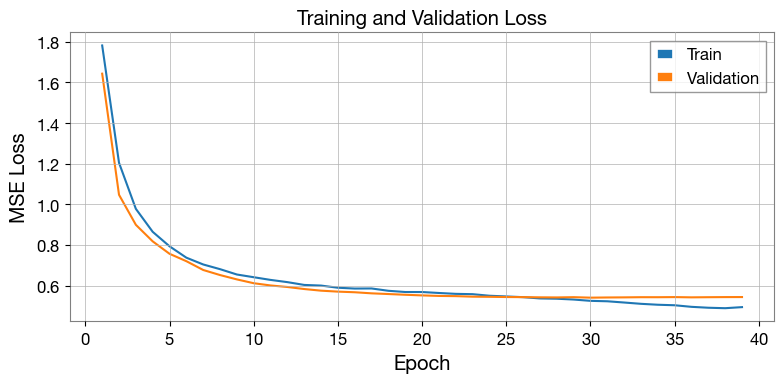

In [13]:
epochs_ran = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_ran, train_losses, label="Train",      color="C0")
ax.plot(epochs_ran, val_losses,   label="Validation", color="C1")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## Step 6 — Test on sine-Gaussian injections

We generate fresh test examples — PyCBC (numpy) noise with a sine-Gaussian injected at a range of SNRs —
and run them through the trained model.
The model was never trained on these specific examples.
We use three different test examples at three different SNRs, reporting the SNR and mismatch ($\mathcal{M}$) above each plot. 
Intuitively, the model better recovers louder glitches than quieter ones. 
The reconstructions below feature high-frequency artifacts as the model training did not fully converge, and it is a reduced architecture compared to the published version. 
Improved performance can be achieved by training this model until convergence or by modifying the layers of DeepExtractor's U-Net to the published architecture, and increasing the resolution of the STFT spectrograms (please see above).

In [16]:
def reconstruct(noisy_signal, model, scaler, device, n_fft, hop_length, win_length):
    """Scale → STFT → U-Net → iSTFT → unscale → subtract background."""
    # Scale
    scaled = scaler.transform(noisy_signal.reshape(-1, 1)).reshape(noisy_signal.shape)

    # STFT
    window = torch.hann_window(win_length)
    t = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0)  # (1, time)
    stft = torch.stft(t, n_fft=n_fft, hop_length=hop_length, win_length=win_length,
                      window=window, return_complex=True)
    mag   = torch.abs(stft)
    phase = torch.angle(stft)
    spec  = torch.stack([mag, phase], dim=1)  # (1, 2, F, T)

    # U-Net inference
    model.eval()
    with torch.no_grad():
        bg_spec = model(spec.to(device)).cpu()  # predicted background spectrogram

    # iSTFT
    bg_mag   = bg_spec[:, 0, :, :]
    bg_phase = bg_spec[:, 1, :, :]
    bg_complex = bg_mag * torch.exp(1j * bg_phase)
    bg_td = torch.istft(bg_complex, n_fft=n_fft, hop_length=hop_length,
                        win_length=win_length, window=window,
                        length=noisy_signal.shape[-1])

    # Unscale and subtract background to recover signal
    bg_unscaled = scaler.inverse_transform(bg_td.numpy().reshape(-1, 1)).reshape(-1)
    noisy_unscaled = noisy_signal.copy()
    reconstruction = noisy_unscaled - bg_unscaled
    return reconstruction

Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...


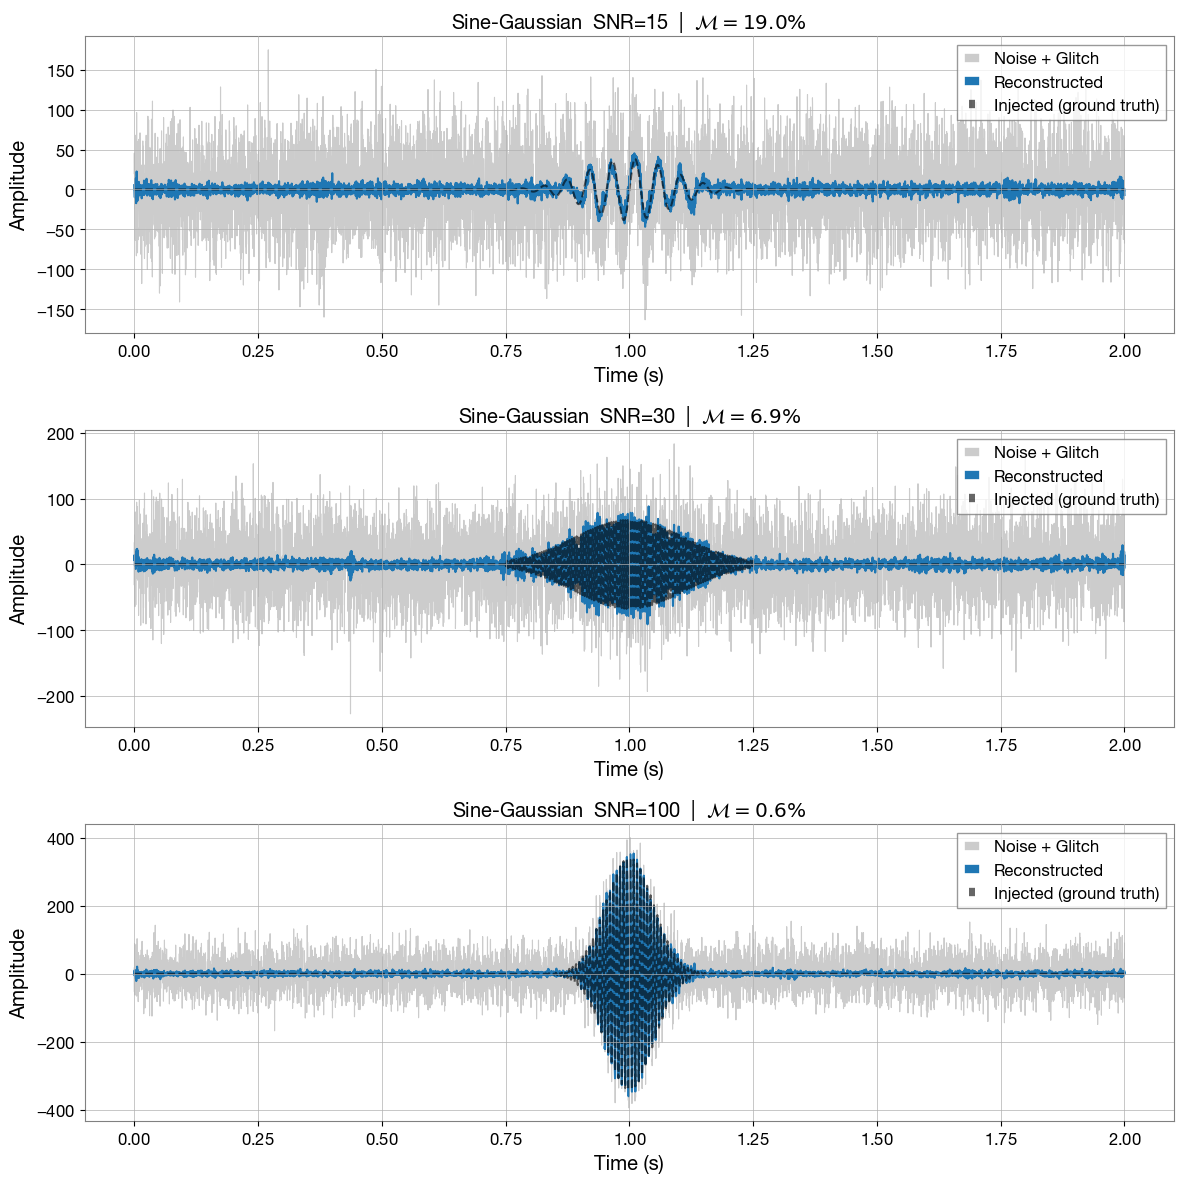

In [15]:
T_INJ = T / 2
SNR_VALUES = [15, 30, 100]

def overlap(a, b):
    """Normalised time-domain overlap (match) between two real signals.
    Equivalent to the PyCBC match on whitened data (flat PSD)."""
    return np.dot(a, b) / np.sqrt(np.dot(a, a) * np.dot(b, b))

fig, axes = plt.subplots(len(SNR_VALUES), 1, figsize=(12, 4 * len(SNR_VALUES)))
t_axis = np.linspace(0, T, LENGTH)

for ax, snr in zip(axes, SNR_VALUES):
    noise = generate_gaussian_noise(mean, std_dev, 1, (LENGTH,), bilby_noise=False)[0]
    
    # We set freq_max=256 when generating the sine-Gaussians for visualization purposes. This can be increased to the Nyquist frequency (i.e. freq_max=2048).
    _, wavelet = generate_sine_gaussian(duration=0.5, freq_max=256)
    wavelet = wavelet - np.mean(wavelet)
    wavelet = whitened_snr_scaling(wavelet, snr=snr)

    len_glitch = len(wavelet)
    id_start   = int(T_INJ * SAMPLE_RATE) - len_glitch // 2
    noisy      = noise.copy()
    noisy[id_start : id_start + len_glitch] += wavelet

    injected = np.zeros(LENGTH)
    injected[id_start : id_start + len_glitch] = wavelet

    reconstructed = reconstruct(noisy, model, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH)

    match    = overlap(injected, reconstructed)
    mismatch = 1.0 - match

    ax.plot(t_axis, noisy,         color="gray",  lw=0.8, alpha=0.4, label="Noise + Glitch")
    ax.plot(t_axis, reconstructed, color="C0",    lw=1.5, label="Reconstructed")
    ax.plot(t_axis, injected,      color="black", lw=1.5, alpha=0.6, linestyle="--", label="Injected (ground truth)")
    ax.set_title(
        f"Sine-Gaussian  SNR={snr}  |  "
        f"$\\mathcal{{M}} = {mismatch*100:.1f} \% $"
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")
    ax.grid(True)

plt.tight_layout()
plt.show()


---

# Part II — Hackathon Tasks

The tutorial above trained a baseline DeepExtractor (STFT U-Net) on synthetic data.
Now try four targeted experiments — each changes **one** aspect of the pipeline.
All tasks share the **same fixed test set** (generated below) so results are comparable.

| Task | What you change | Key question |
|------|----------------|-------------|
| 1 | Number of U-Net encoder levels | How does model depth affect quality? |
| 2 | Model domain: STFT → 1-D time-domain | Does operating on raw waveforms help? |
| 3 | Training-set size `N_TRAIN` | How much data do we really need? |
| 4 | Synthetic training signal types | Does a diverse training set generalise better? |

> **LISA / Mojito note** — This tutorial runs at `SAMPLE_RATE = 4096 Hz, T = 2 s, LENGTH = 8192`.
> The [Mojito LISA dataset](https://mojito-e66317.io.esa.int/) uses `dt = 2.0 s` (0.5 Hz) with
> 1000-sample windows. For LISA-compatible parameters set `SAMPLE_RATE = 0.5` and `T = 16384.0`
> in the Configuration cell, re-run from the top, and adjust signal durations/frequencies
> (e.g. duration range 20–8000 s, `freq_max = SAMPLE_RATE / 2 = 0.25` Hz).

In [18]:
# --- Optional: install gengli for out-of-sample blip testing (Task 4) ----------
try:
    import gengli
    GENGLI_AVAILABLE = True
    print("gengli available.")
except ImportError:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "gengli", "-q"])
        import gengli
        GENGLI_AVAILABLE = True
        print("gengli installed.")
    except Exception:
        GENGLI_AVAILABLE = False
        print("gengli not available — blip test in Task 4 will be skipped.")

# --- Fixed test set (sine-Gaussian injections at three SNRs) ------------------
# Seeded once; do NOT re-run this cell mid-session to keep comparisons fair.
import random as _random
_random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

_N_PER_SNR  = 10
_SNR_VALS   = [15, 30, 100]
_T_INJ_TEST = T / 2

_noisy_buf, _inj_buf, _snr_buf = [], [], []
for _snr in _SNR_VALS:
    for _ in range(_N_PER_SNR):
        _n   = generate_gaussian_noise(mean, std_dev, 1, (LENGTH,), bilby_noise=False)[0]
        _, _w = generate_sine_gaussian(duration=0.5, freq_max=256)
        _w   = _w - np.mean(_w)
        _w   = whitened_snr_scaling(_w, snr=_snr)
        _L   = len(_w)
        _i0  = int(_T_INJ_TEST * SAMPLE_RATE) - _L // 2
        _nn  = _n.copy()
        _nn[_i0:_i0 + _L] += _w
        _ij  = np.zeros(LENGTH)
        _ij[_i0:_i0 + _L] = _w
        _noisy_buf.append(_nn)
        _inj_buf.append(_ij)
        _snr_buf.append(_snr)

TEST_NOISY    = np.array(_noisy_buf)    # (30, LENGTH)
TEST_INJECTED = np.array(_inj_buf)      # (30, LENGTH)
TEST_SNRS     = np.array(_snr_buf)
print(f"Fixed test set ready: {len(TEST_NOISY)} examples, SNRs = {_SNR_VALS}")

gengli available.
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...
Fixed test set ready: 30 examples, SNRs = [15, 30, 100]


In [19]:
# --- Shared helpers used by all four tasks ------------------------------------
EPOCHS_TASK = 20   # reduce to 10 for quicker runs; increase for better convergence


def _train_stft(mdl, tr_ld, vl_ld, epochs=EPOCHS_TASK):
    # Train an STFT model (or any model whose loader yields 2-D spectrograms).
    _lfn = nn.MSELoss()
    _opt = optim.Adam(mdl.parameters(), lr=LR)
    _sch = ReduceLROnPlateau(_opt, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
    _amp = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else torch.amp.GradScaler("cpu", enabled=False)
    tr_ls, vl_ls = [], []
    best_v, es_c = float("inf"), 0
    for ep in range(epochs):
        tl, _, _ = train_fn(tr_ld, mdl, "generic", _opt, _lfn, _amp, DEVICE)
        vl, _, _ = check_accuracy(vl_ld, mdl, "generic", device=DEVICE)
        tr_ls.append(tl)
        vl_ls.append(vl)
        _sch.step(vl)
        print(f"  ep {ep+1:>2}/{epochs}  train={tl:.5f}  val={vl:.5f}")
        if vl < best_v:
            best_v = vl
            es_c   = 0
        else:
            es_c += 1
            if es_c >= EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping at epoch {ep+1}.")
                break
    return tr_ls, vl_ls


def _mismatch_stft(mdl, scl=None):
    # Mean mismatch of an STFT model on the fixed test set.
    if scl is None:
        scl = scaler
    mm = [
        1.0 - overlap(inj, reconstruct(noisy, mdl, scl, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))
        for noisy, inj in zip(TEST_NOISY, TEST_INJECTED)
    ]
    return float(np.mean(mm))


def _mismatch_1d(mdl, scl=None):
    # Mean mismatch of a 1-D time-domain model on the fixed test set.
    if scl is None:
        scl = scaler
    mdl.eval()
    mm = []
    with torch.no_grad():
        for noisy, inj in zip(TEST_NOISY, TEST_INJECTED):
            sc_in  = scl.transform(noisy.reshape(-1, 1)).reshape(1, 1, -1)
            inp    = torch.tensor(sc_in, dtype=torch.float32).to(DEVICE)
            out    = mdl(inp).cpu().numpy().squeeze()
            bg_raw = scl.inverse_transform(out.reshape(-1, 1)).reshape(-1)
            mm.append(1.0 - overlap(inj, noisy - bg_raw))
    mdl.train()
    return float(np.mean(mm))


def _plot_val_curves(loss_dict, title="Validation Loss"):
    fig, ax = plt.subplots(figsize=(8, 4))
    for lbl, (_, vl) in loss_dict.items():
        ax.plot(range(1, len(vl) + 1), vl, label=lbl)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## Task 1 — Effect of Model Depth

The baseline model uses `features = [32, 64, 128, 256]` (4 encoder levels).
Shallower models train faster but may lack capacity; deeper ones risk overfitting on small datasets.

**TODO:** Run the comparison below as-is, then add a 5th level (`[..., 512]`) or strip
it back to a single level and observe how the validation loss and test mismatch change.

*Discussion questions:*
- At what depth does adding more layers stop helping?
- Do you see signs of overfitting (val loss rising while train loss falls)?


────────────────────────────────────────────────────────────
Training: 2-layer [32,64]  (466,914 params)


Training on batch: 100%|██████████| 32/32 [00:07<00:00,  4.33it/s, loss=1.51]


Validation Loss: 1.842396
  ep  1/20  train=1.97619  val=1.84240


Training on batch: 100%|██████████| 32/32 [00:06<00:00,  4.66it/s, loss=1.18]


Validation Loss: 1.157481
  ep  2/20  train=1.32166  val=1.15748


...

Validation Loss: 0.561657
  ep 18/20  train=0.53844  val=0.56166


Training on batch: 100%|██████████| 32/32 [00:12<00:00,  2.52it/s, loss=0.525]


Validation Loss: 0.562531
  ep 19/20  train=0.53070  val=0.56253


Training on batch: 100%|██████████| 32/32 [00:12<00:00,  2.50it/s, loss=0.527]


Validation Loss: 0.562766
  ep 20/20  train=0.52310  val=0.56277
  Mean test mismatch: 11.78 %


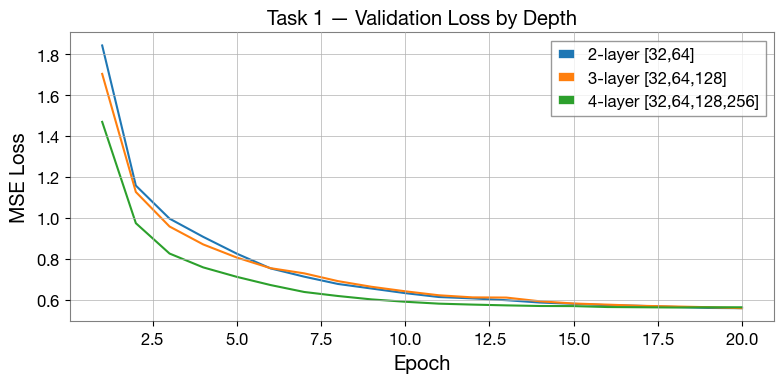

In [20]:
# --- Task 1: compare U-Net depths --------------------------------------------
# TODO: add or remove entries in features_configs to explore other depths
features_configs = {
    "2-layer [32,64]":           [32, 64],
    "3-layer [32,64,128]":       [32, 64, 128],
    "4-layer [32,64,128,256]":   [32, 64, 128, 256],   # matches baseline above
}

task1_curves    = {}   # label -> (train_losses, val_losses)
task1_mismatch  = {}   # label -> mean mismatch on TEST_NOISY

for lbl, feats in features_configs.items():
    print(f"\n{'─'*60}")
    print(f"Training: {lbl}  ({sum(p.numel() for p in UNET2D(2,2,feats).parameters()):,} params)")
    mdl = UNET2D(in_channels=2, out_channels=2, features=feats).to(DEVICE)
    tr_ls, vl_ls     = _train_stft(mdl, train_loader, val_loader)
    task1_curves[lbl]   = (tr_ls, vl_ls)
    task1_mismatch[lbl] = _mismatch_stft(mdl)
    print(f"  Mean test mismatch: {task1_mismatch[lbl]*100:.2f} %")

_plot_val_curves(task1_curves, title="Task 1 — Validation Loss by Depth")

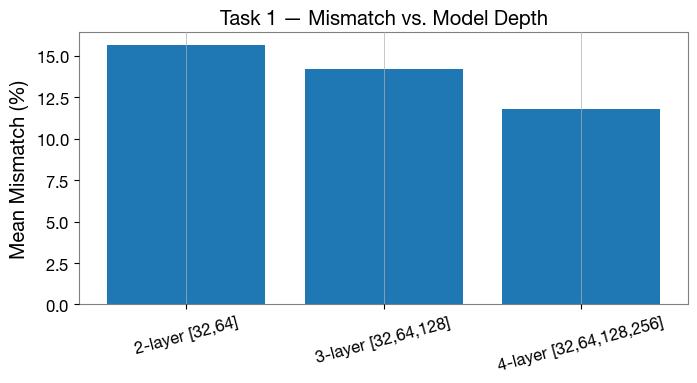

  2-layer [32,64]: 15.62 %
  3-layer [32,64,128]: 14.22 %
  4-layer [32,64,128,256]: 11.78 %


In [21]:
# Task 1 summary bar chart
fig, ax = plt.subplots(figsize=(7, 4))
lbls = list(task1_mismatch.keys())
vals = [task1_mismatch[l] * 100 for l in lbls]
ax.bar(lbls, vals, color="C0")
ax.set_ylabel("Mean Mismatch (%)")
ax.set_title("Task 1 — Mismatch vs. Model Depth")
ax.tick_params(axis="x", labelrotation=15)
ax.grid(axis="y")
plt.tight_layout()
plt.show()
for l, v in zip(lbls, vals):
    print(f"  {l}: {v:.2f} %")

## Task 2 — Time-Domain vs. STFT Model

DeepExtractor normally operates on **STFT spectrograms** (magnitude + phase, shape `(2, 129, 129)`).
`UNET1D` instead processes the **raw 1-D waveform** directly — no frequency transform.

| | Input shape | Ops | Params (same depth) |
|--|------------|-----|---------------------|
| `UNET2D` (STFT) | `(B, 2, 129, 129)` | 2-D convolutions | ~7 M |
| `UNET1D` (TD) | `(B, 1, 8192)` | 1-D convolutions | ~3 M |

**TODO:** Run the cells below to train the 1-D model, then compare its mismatch against
the STFT baseline.

*Discussion questions:*
- Which model achieves lower mismatch?
- Is the time-domain model faster or slower to train per epoch?
- What information does the STFT representation preserve that the time domain does not?

In [22]:
# --- Task 2: 1-D DataLoaders (reuse already-scaled arrays) -------------------
from deepextractor.models.architectures import UNET1D

# Add a channel dimension: (N, LENGTH) -> (N, 1, LENGTH)
x_tr_1d = torch.tensor(glitch_train_scaled, dtype=torch.float32).unsqueeze(1)
y_tr_1d = torch.tensor(bg_train_scaled,     dtype=torch.float32).unsqueeze(1)
x_vl_1d = torch.tensor(glitch_val_scaled,   dtype=torch.float32).unsqueeze(1)
y_vl_1d = torch.tensor(bg_val_scaled,       dtype=torch.float32).unsqueeze(1)

train_ds_1d     = TensorDataset(x_tr_1d, y_tr_1d)
val_ds_1d       = TensorDataset(x_vl_1d, y_vl_1d)
train_loader_1d = DataLoader(train_ds_1d, batch_size=BATCH_SIZE, shuffle=True)
val_loader_1d   = DataLoader(val_ds_1d,   batch_size=BATCH_SIZE, shuffle=False)
print(f"1-D input shape: {x_tr_1d.shape}")

1-D input shape: torch.Size([1000, 1, 8192])


In [23]:
# --- Task 2: train UNET1D and compare with STFT baseline --------------------
model_1d = UNET1D(in_channels=1, out_channels=1, features=[32, 64, 128, 256]).to(DEVICE)
print(f"UNET1D parameters: {sum(p.numel() for p in model_1d.parameters()):,}")

print("\nTraining UNET1D (time-domain)...")
trl_1d, vll_1d = _train_stft(model_1d, train_loader_1d, val_loader_1d)
mm_1d = _mismatch_1d(model_1d)
print(f"\nUNET1D  mean test mismatch : {mm_1d*100:.2f} %")

# Retrieve STFT result from Task 1 (4-layer) or re-evaluate the baseline
_stft_lbl = "4-layer [32,64,128,256]"
mm_stft   = task1_mismatch.get(_stft_lbl, _mismatch_stft(model))
print(f"UNET2D  mean test mismatch : {mm_stft*100:.2f} %")

UNET1D parameters: 2,707,809

Training UNET1D (time-domain)...


Training on batch: 100%|██████████| 32/32 [00:17<00:00,  1.83it/s, loss=0.0364]


Validation Loss: 0.030803
  ep  1/20  train=0.05326  val=0.03080


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.24it/s, loss=0.0262]


Validation Loss: 0.025569
  ep  2/20  train=0.02853  val=0.02557


...

Validation Loss: 0.016353
  ep 18/20  train=0.01705  val=0.01635


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.18it/s, loss=0.0175]


Validation Loss: 0.016186
  ep 19/20  train=0.01686  val=0.01619


Training on batch: 100%|██████████| 32/32 [00:15<00:00,  2.08it/s, loss=0.0188]


Validation Loss: 0.016031
  ep 20/20  train=0.01671  val=0.01603

UNET1D  mean test mismatch : 25.59 %
UNET2D  mean test mismatch : 11.78 %


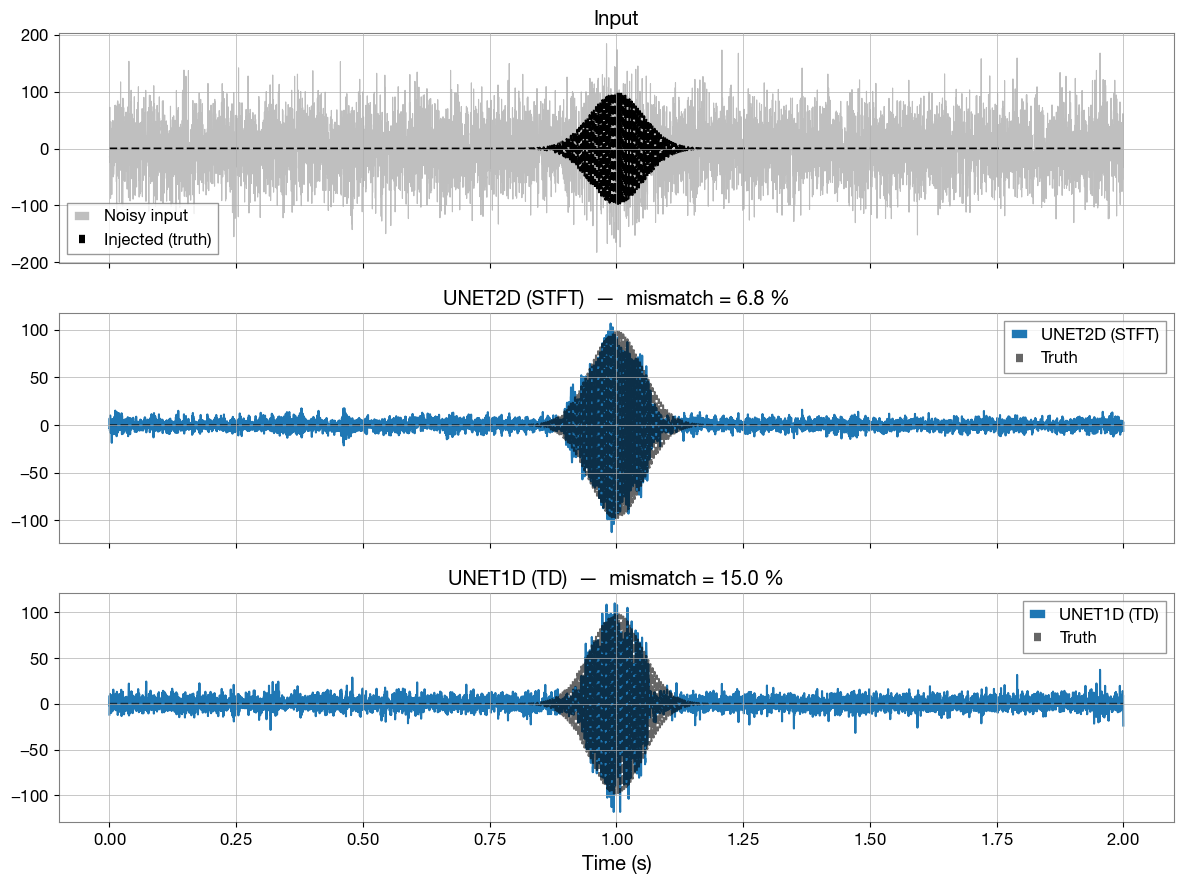

In [24]:
# Task 2: side-by-side reconstruction at SNR=30 for one test example
_idx    = int(np.where(TEST_SNRS == 30)[0][0])
_noisy  = TEST_NOISY[_idx]
_inj    = TEST_INJECTED[_idx]
t_axis  = np.linspace(0, T, LENGTH)

_r_stft = reconstruct(_noisy, model, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH)

model_1d.eval()
with torch.no_grad():
    _sc  = scaler.transform(_noisy.reshape(-1, 1)).reshape(1, 1, -1)
    _out = model_1d(torch.tensor(_sc, dtype=torch.float32).to(DEVICE)).cpu().numpy().squeeze()
    _bg  = scaler.inverse_transform(_out.reshape(-1, 1)).reshape(-1)
_r_1d = _noisy - _bg

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t_axis, _noisy, color="gray", lw=0.8, alpha=0.5, label="Noisy input")
axes[0].plot(t_axis, _inj,  color="black", lw=1.5, ls="--", label="Injected (truth)")
axes[0].set_title("Input")
axes[0].legend(); axes[0].grid(True)

for ax, recon, lbl in [(axes[1], _r_stft, "UNET2D (STFT)"),
                       (axes[2], _r_1d,   "UNET1D (TD)")]:
    mm = 1.0 - overlap(_inj, recon)
    ax.plot(t_axis, recon, lw=1.5, label=lbl)
    ax.plot(t_axis, _inj, color="black", lw=1.5, ls="--", alpha=0.6, label="Truth")
    ax.set_title(f"{lbl}  —  mismatch = {mm*100:.1f} %")
    ax.legend(); ax.grid(True)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Task 3 — Effect of Dataset Size

More training data usually improves generalisation — but generating (or labelling) data has a cost.
Here you train the same model architecture on datasets of increasing size and measure how
reconstruction quality on the **fixed test set** changes.

**TODO:** Run the cell below, then add larger values like `2000` or `5000` to
`n_train_values`.

*Discussion questions:*
- Is there a "knee" in the mismatch-vs-N curve after which more data stops helping?
- What does this imply about how much real detector data you would need?


────────────────────────────────────────────────────────────
N_TRAIN = 200
Generating pycbc noise...
Generating pycbc noise...


Generating Synthetic Train Data:   0%|          | 0/200 [00:00<?, ?it/s]/Users/tomdooney/Documents/Work/Projects/deepextractor/src/deepextractor/utils/signal.py:12: RuntimeWarning: divide by zero encountered in divide
  glitch = (glitch.T * snr / np.sqrt(true_sigma_sq)).T
Training on batch: 100%|██████████| 7/7 [00:03<00:00,  1.75it/s, loss=1.89]


Validation Loss: 2.160550
  ep  1/20  train=1.99924  val=2.16055


Training on batch: 100%|██████████| 7/7 [00:02<00:00,  2.47it/s, loss=1.71]


Validation Loss: 2.072416
  ep  2/20  train=1.78770  val=2.07242


...

Validation Loss: 0.578555
  ep 18/20  train=0.53394  val=0.57856


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.19it/s, loss=0.616]


Validation Loss: 0.571555
  ep 19/20  train=0.53429  val=0.57155


Training on batch: 100%|██████████| 32/32 [00:14<00:00,  2.21it/s, loss=0.645]


Validation Loss: 0.571207
  ep 20/20  train=0.52771  val=0.57121
  Mean test mismatch: 12.61 %


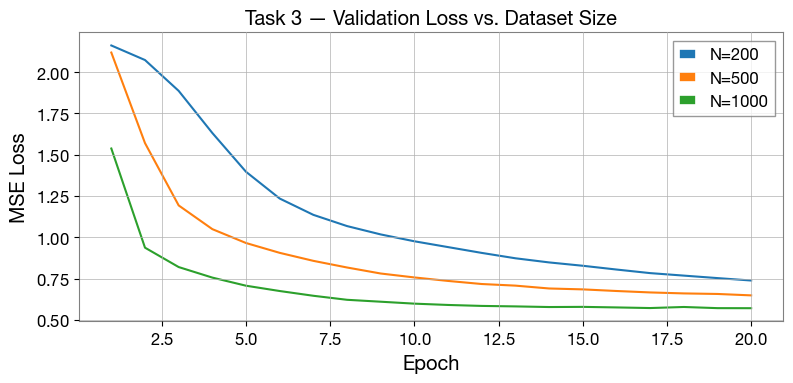

In [25]:
# --- Task 3: vary training-set size ------------------------------------------
# TODO: add more values (e.g. 2000, 5000) to see the full curve
n_train_values = [200, 500, 1000]

task3_curves   = {}
task3_mismatch = {}

for n_tr in n_train_values:
    print(f"\n{'─'*60}\nN_TRAIN = {n_tr}")

    _tr_noise = generate_gaussian_noise(mean, std_dev, n_tr,  (LENGTH,), bilby_noise=False)
    _vl_noise = generate_gaussian_noise(mean, std_dev, N_VAL, (LENGTH,), bilby_noise=False)
    _gl_tr, _bg_tr = generate_synthetic_data(_tr_noise, bilby_noise=False, phase="train")
    _gl_vl, _bg_vl = generate_synthetic_data(_vl_noise, bilby_noise=False, phase="val")

    _sc_gl_tr  = scaler.transform(_gl_tr.reshape(-1, 1)).reshape(_gl_tr.shape)
    _sc_bg_tr  = scaler.transform(_bg_tr.reshape(-1, 1)).reshape(_bg_tr.shape)
    _sc_gl_vl  = scaler.transform(_gl_vl.reshape(-1, 1)).reshape(_gl_vl.shape)
    _sc_bg_vl  = scaler.transform(_bg_vl.reshape(-1, 1)).reshape(_bg_vl.shape)

    _sp_gl_tr  = to_mag_phase(_sc_gl_tr)
    _sp_bg_tr  = to_mag_phase(_sc_bg_tr)
    _sp_gl_vl  = to_mag_phase(_sc_gl_vl)
    _sp_bg_vl  = to_mag_phase(_sc_bg_vl)

    _ld_tr = DataLoader(TensorDataset(_sp_gl_tr, _sp_bg_tr), batch_size=BATCH_SIZE, shuffle=True)
    _ld_vl = DataLoader(TensorDataset(_sp_gl_vl, _sp_bg_vl), batch_size=BATCH_SIZE, shuffle=False)

    _mdl = UNET2D(in_channels=2, out_channels=2, features=[32, 64, 128, 256]).to(DEVICE)
    tr_ls, vl_ls           = _train_stft(_mdl, _ld_tr, _ld_vl)
    task3_curves[f"N={n_tr}"]   = (tr_ls, vl_ls)
    task3_mismatch[f"N={n_tr}"] = _mismatch_stft(_mdl)
    print(f"  Mean test mismatch: {task3_mismatch[f'N={n_tr}']*100:.2f} %")

_plot_val_curves(task3_curves, title="Task 3 — Validation Loss vs. Dataset Size")

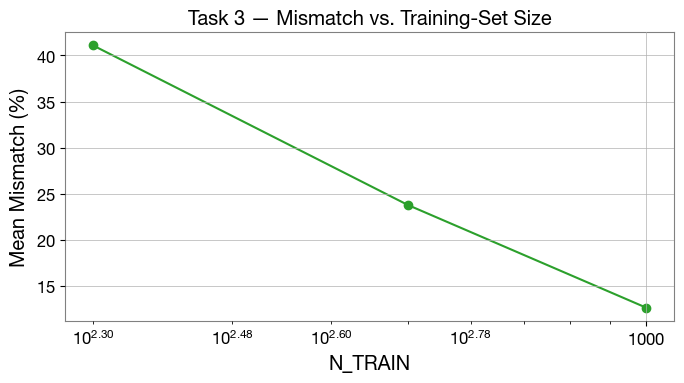

In [26]:
# Task 3 summary: mismatch as a function of N_TRAIN
ns   = [int(k.split("=")[1]) for k in task3_mismatch]
mms  = [task3_mismatch[k] * 100 for k in task3_mismatch]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, mms, "o-", color="C2")
ax.set_xlabel("N_TRAIN")
ax.set_ylabel("Mean Mismatch (%)")
ax.set_title("Task 3 — Mismatch vs. Training-Set Size")
ax.set_xscale("log")
ax.grid(True)
plt.tight_layout()
plt.show()

## Task 4 — Basis Functions & Out-of-Sample Generalisation

The default training set mixes all five synthetic signal types
(chirps, sines, sine-Gaussians, Gaussian pulses, ringdowns).
What happens if the model sees only **one** type during training?

You will train two models and compare them on:
1. **In-sample** — the fixed sine-Gaussian test set above
2. **Out-of-sample (ringdowns)** — synthetic ringdown glitches (no extra install)
3. **Out-of-sample (gengli blips)** *(optional, if gengli is installed)* — a proxy for
   real LIGO detector transients; treated here as raw sample arrays at whatever rate
   you are training at (the "dimensionality convention" rather than a physical resample)

**TODO:** Run as-is, then try changing `SIGNAL_TYPES_B` to other combinations
(e.g. only chirps + ringdowns) and see which mix generalises best to blip glitches.

*Discussion questions:*
- Which model performs better in-sample? Out-of-sample?
- Is a diverse training set always better?

In [28]:
# --- Task 4: custom data generator with selectable signal types ---------------
from deepextractor.generation.generate_timeseries import SNR_MIN, SNR_MAX
import random as _rand4
from tqdm.auto import tqdm as _tqdm4
from deepextractor.generation.glitch_functions import (
    generate_chirp       as _gen_chirp,
    generate_sine        as _gen_sine,
    generate_sine_gaussian as _gen_sg4,
    generate_gaussian_pulse as _gen_gp,
    ringdown             as _gen_rd,
)

_FN4 = {
    "chirp":          _gen_chirp,
    "sine":           _gen_sine,
    "sine_gaussian":  _gen_sg4,
    "gaussian_pulse": _gen_gp,
    "ringdown":       _gen_rd,
}
_T_INJ4 = T / 2


def _gen_typed(noise_arr, sig_types, label=""):
    glitches, bgs = [], []
    for bg in _tqdm4(noise_arr, desc=f"Generating {label}"):
        noisy = bg.copy()
        for _ in range(np.random.randint(1, 30)):
            s_type   = _rand4.choice(sig_types)
            duration = np.random.uniform(0.125, T)
            _, sig   = _FN4[s_type](duration)
            if len(sig) == 0 or np.isnan(sig).any():
                continue
            sig  = sig - np.mean(sig)
            sig  = whitened_snr_scaling(sig, snr=np.random.uniform(SNR_MIN, SNR_MAX))
            L    = len(sig)
            id0  = int(_T_INJ4 * SAMPLE_RATE) - L // 2
            if id0 < 0 or id0 + L > LENGTH:
                continue
            hi   = max(1, LENGTH - id0 - L)
            if -id0 >= hi:
                continue
            sh   = np.random.randint(-id0, hi)
            s, e = id0 + sh, min(id0 + sh + L, LENGTH)
            noisy[s:e] += sig[:e - s]
        glitches.append(noisy)
        bgs.append(bg)
    g, b = np.array(glitches), np.array(bgs)
    ok = ~np.any(np.isnan(g) | np.isinf(g) | (np.abs(g) > np.finfo(np.float64).max), axis=1)
    return g[ok], b[ok]


def _spec_loaders(gl, bg, gl_vl, bg_vl):
    def _spec(a):
        sc = scaler.transform(a.reshape(-1, 1)).reshape(a.shape)
        return to_mag_phase(sc)
    ld_tr = DataLoader(TensorDataset(_spec(gl),    _spec(bg)),    batch_size=BATCH_SIZE, shuffle=True)
    ld_vl = DataLoader(TensorDataset(_spec(gl_vl), _spec(bg_vl)), batch_size=BATCH_SIZE, shuffle=False)
    return ld_tr, ld_vl


# TODO: change SIGNAL_TYPES_B to try different training mixes
SIGNAL_TYPES_A = ["sine_gaussian"]
SIGNAL_TYPES_B = ["chirp", "sine", "sine_gaussian", "gaussian_pulse", "ringdown"]

_t4_tr_noise = generate_gaussian_noise(mean, std_dev, N_TRAIN, (LENGTH,), bilby_noise=False)
_t4_vl_noise = generate_gaussian_noise(mean, std_dev, N_VAL,   (LENGTH,), bilby_noise=False)

print(f"Model A: {SIGNAL_TYPES_A}")
_gl_A,  _bg_A  = _gen_typed(_t4_tr_noise.copy(), SIGNAL_TYPES_A, "Model A train")
_glv_A, _bgv_A = _gen_typed(_t4_vl_noise.copy(), SIGNAL_TYPES_A, "Model A val")

print(f"\nModel B: {SIGNAL_TYPES_B}")
_gl_B,  _bg_B  = _gen_typed(_t4_tr_noise.copy(), SIGNAL_TYPES_B, "Model B train")
_glv_B, _bgv_B = _gen_typed(_t4_vl_noise.copy(), SIGNAL_TYPES_B, "Model B val")

ld_A_tr, ld_A_vl = _spec_loaders(_gl_A,  _bg_A,  _glv_A, _bgv_A)
ld_B_tr, ld_B_vl = _spec_loaders(_gl_B,  _bg_B,  _glv_B, _bgv_B)
print("Data ready.")

Generating pycbc noise...
Generating pycbc noise...
Model A: ['sine_gaussian']


Generating Model A train:   0%|          | 0/1000 [00:00<?, ?it/s]


NameError: name 'SNR_MIN' is not defined

In [ ]:
# --- Task 4: train Model A and Model B ---------------------------------------
print("Training Model A (sine-Gaussian only)...")
model_A = UNET2D(in_channels=2, out_channels=2, features=[32, 64, 128, 256]).to(DEVICE)
trl_A, vll_A = _train_stft(model_A, ld_A_tr, ld_A_vl)

print("\nTraining Model B (all 5 types)...")
model_B = UNET2D(in_channels=2, out_channels=2, features=[32, 64, 128, 256]).to(DEVICE)
trl_B, vll_B = _train_stft(model_B, ld_B_tr, ld_B_vl)

_plot_val_curves(
    {"Model A (SG only)": (trl_A, vll_A), "Model B (all types)": (trl_B, vll_B)},
    title="Task 4 — Training Curves",
)

In [ ]:
# --- Task 4: in-sample test (sine-Gaussians) ---------------------------------
mm_A_sg = _mismatch_stft(model_A)
mm_B_sg = _mismatch_stft(model_B)
print(f"In-sample (sine-Gaussians):")
print(f"  Model A: {mm_A_sg*100:.2f} %   Model B: {mm_B_sg*100:.2f} %")

# --- Out-of-sample: ringdown glitches (no extra install needed) ---------------
_oos_noise = generate_gaussian_noise(mean, std_dev, 30, (LENGTH,), bilby_noise=False)
_T_OOS = T / 2
_oos_noisy_list, _oos_inj_list = [], []
for _n in _oos_noise:
    _, _rd = _gen_rd(duration=np.random.uniform(0.125, T))
    _rd = _rd - np.mean(_rd)
    _rd = whitened_snr_scaling(_rd, snr=np.random.uniform(30, 100))
    _L  = len(_rd)
    _i0 = int(_T_OOS * SAMPLE_RATE) - _L // 2
    if _i0 < 0 or _i0 + _L > LENGTH:
        continue
    _nn = _n.copy()
    _nn[_i0:_i0 + _L] += _rd
    _ij = np.zeros(LENGTH)
    _ij[_i0:_i0 + _L] = _rd
    _oos_noisy_list.append(_nn)
    _oos_inj_list.append(_ij)
_oos_n  = np.array(_oos_noisy_list)
_oos_ij = np.array(_oos_inj_list)

mm_A_rd = float(np.mean([
    1 - overlap(ij, reconstruct(n, model_A, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))
    for n, ij in zip(_oos_n, _oos_ij)
]))
mm_B_rd = float(np.mean([
    1 - overlap(ij, reconstruct(n, model_B, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))
    for n, ij in zip(_oos_n, _oos_ij)
]))
print(f"Out-of-sample (ringdowns):")
print(f"  Model A: {mm_A_rd*100:.2f} %   Model B: {mm_B_rd*100:.2f} %")

# --- Optional: gengli blip glitches ------------------------------------------
mm_A_bl = mm_B_bl = None
if GENGLI_AVAILABLE:
    import gengli as _gengli
    _ggen   = _gengli.glitch_generator("H1")
    _bl_noisy_list, _bl_inj_list = [], []
    for _n in _oos_noise[:20]:
        _blip = np.array(_ggen.get_glitch(1, srate=4096, snr=10, alpha=0.2, fhigh=1024)).squeeze()
        _blip = _blip - np.mean(_blip)
        _blip = whitened_snr_scaling(_blip, snr=30)
        _L    = min(len(_blip), LENGTH)
        _i0   = max(0, int(_T_OOS * SAMPLE_RATE) - _L // 2)
        _i0   = min(_i0, LENGTH - _L)
        _nn   = _n.copy()
        _nn[_i0:_i0 + _L]  += _blip[:_L]
        _ij = np.zeros(LENGTH)
        _ij[_i0:_i0 + _L]   = _blip[:_L]
        _bl_noisy_list.append(_nn)
        _bl_inj_list.append(_ij)
    _bl_n  = np.array(_bl_noisy_list)
    _bl_ij = np.array(_bl_inj_list)
    mm_A_bl = float(np.mean([
        1 - overlap(ij, reconstruct(n, model_A, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))
        for n, ij in zip(_bl_n, _bl_ij)
    ]))
    mm_B_bl = float(np.mean([
        1 - overlap(ij, reconstruct(n, model_B, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH))
        for n, ij in zip(_bl_n, _bl_ij)
    ]))
    print(f"Out-of-sample (gengli blips, raw samples treated as training-rate data):")
    print(f"  Model A: {mm_A_bl*100:.2f} %   Model B: {mm_B_bl*100:.2f} %")
else:
    print("(gengli not installed — blip test skipped)")

In [ ]:
# Task 4 summary: grouped bar chart
_cats = ["In-sample\n(sine-Gaussian)", "Out-of-sample\n(ringdown)"]
_mA   = [mm_A_sg * 100, mm_A_rd * 100]
_mB   = [mm_B_sg * 100, mm_B_rd * 100]

if mm_A_bl is not None:
    _cats.append("Out-of-sample\n(gengli blips)")
    _mA.append(mm_A_bl * 100)
    _mB.append(mm_B_bl * 100)

x   = np.arange(len(_cats))
w   = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w / 2, _mA, w, label="Model A (SG only)", color="C0")
ax.bar(x + w / 2, _mB, w, label="Model B (all types)", color="C1")
ax.set_xticks(x)
ax.set_xticklabels(_cats)
ax.set_ylabel("Mean Mismatch (%)")
ax.set_title("Task 4 — In-sample vs. Out-of-sample Generalisation")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()